# UNET - F2 - AmaroXI - 1.2 M

## Libraries

In [1]:
import h5py
import numpy as np
from typing import *
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import os
import glob
import keras
import time
import sys
import asyncio

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Data

In [3]:
n = 1
size = [
    1080000//n,
    108000//n,
    12000//n
]

In [4]:
def normalization_by_sample(x, p = False) -> np.ndarray:
    '''Normalize the array by taking a max and min value over a sample.

    Args:
        x: A NumPy array of shape (n, m), where n is the number of samples and m is the number of features.

    Returns:
        A NumPy array of the same shape (n, m), normalized by sample.
    '''

    mi = np.min(x, axis = 1, keepdims=True)
    ma = np.max(x, axis = 1, keepdims=True)
    if p: print(ma)
    if p: print(mi)

    return (x - mi) / (ma - mi + 1e-6)

In [5]:
def load_data_normalization_sample_General(folder: str,
                                  size: list = [0, 0, 0],
                                  names: list = ['x_total', 'y_total'] ) ->  Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    '''
    Description:
        The next function takes in the path of the folder where the train, val y test dataset are storage, the function iterates
        over the folder and select the .h5 files. In returns the x, y datasets of each train, test y val dataset.

    Args
        folder (str): Get the path of the folder containing the datasets train, val y test in .h5 format
        size (list): Ints of samples to be taken of each dataset: train, test y val

    Return
        x_train (numpy array): Train dataset of x
        y_train (numpy array): Train dataset of y

        x_test (numpy array): Test dataset of x
        y_test (numpy array): Test dataset of y

        x_val (numpy array): Validation dataset of x
        y_val (numpy array): Validation dataset of y
    '''

    _datapath_list = glob.glob(folder + '/*.h5')

    for path in _datapath_list:
        if 'train' in path:
            f1 = h5py.File(path, 'r')

        elif 'test' in path:
            f2 = h5py.File(path, 'r')

        elif 'val' in path:
            f3 = h5py.File(path, 'r')

    if size[0]> 0:
        _xtrain = normalization_by_sample(f1[names[0]][:size[0]])
        _ytrain = f1[names[1]][:size[0]]

        _xtest, _ytest = normalization_by_sample(f2[names[0]][:size[1]]), f2[names[1]][:size[1]]

        _xval, _yval = normalization_by_sample(f3[names[0]][:size[2]]), f3[names[1]][:size[2]]

        return (_xtrain, _ytrain, _xtest, _ytest, _xval, _yval)

    else:

        _xtrain = normalization_by_sample(f1[names[0]][:])
        _ytrain = f1[names[1]][:]

        _xtest, _ytest = normalization_by_sample(f2[names[0]][:]), f2[names[1]][:]

        _xval, _yval = normalization_by_sample(f3[names[0]][:]), f3[names[1]][:]

        return (_xtrain, _ytrain, _xtest, _ytest, _xval, _yval)


    f1.close()
    f2.close()
    f3.close()

In [6]:
data = load_data_normalization_sample_General(
    folder = '/content/drive/MyDrive/AzONet/notebooks/3_data_simulation/NewDataAzONetV2/Sets',
    #size = size
)

In [7]:
def show_dimensions(data: tuple) -> None:
    dims = [ dat.shape for dat in data]
    print('''
--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train:
    x: {}
    y: {}

Test:
    x: {}
    y: {}

Val:
    x: {}
    y: {}
    '''.format(dims[0], dims[1], dims[2], dims[3], dims[4], dims[5] ) )

In [8]:
show_dimensions(data)


--------------------------------------------------
The dimensions of each dataset corresponds to:
--------------------------------------------------

Train: 
    x: (960000, 911, 1)
    y: (960000, 1)

Test: 
    x: (120000, 911, 1)
    y: (120000, 1)

Val:
    x: (120000, 911, 1)
    y: (120000, 1)
    


In [9]:
def plot_xy(data: tuple) -> None:
    '''
    Description:
        This function plots a random element in the training data and, if exists, the corresponding y element
    '''

    figure = plt.Figure(figsize = (12, 12))
    n = random.randint(0, data[0].shape[0])
    plt.plot(data[0][n], label = 'x element')
    plt.title('A random element in the x trainining dataset')
    plt.grid(True)
    plt.legend()
    plt.show()

    if len(data)>1: print('The corresponding y element ->', data[1][n])


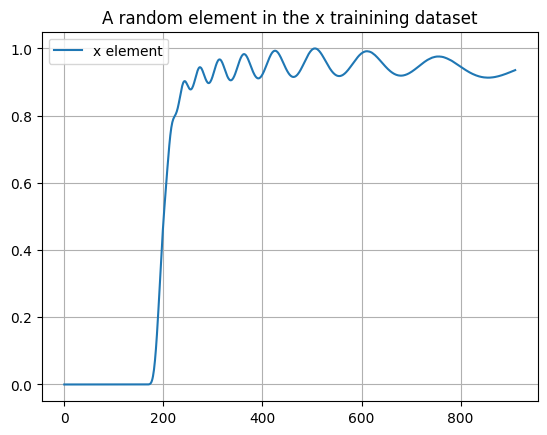

The corresponding y element -> [1264.1426]


In [10]:
plot_xy(data)

In [11]:
x_train, y_train, x_test, y_test, x_val, y_val = data
del data

## GPU Allocation

In [12]:
#! nvidia-smi

In [13]:
def get_gpu(gpu_number: int = 2, p: bool = False) -> None:
    '''
    Description:
        This function gets, if available, a GPU.

    Args:
        gpu_number (int): Refering to the GPU to take
        p (bool): Do I must show the total number of GPUS?

    '''
    gpus = tf.config.list_physical_devices('GPU') #se obtiene una lista de todas las gpu's del sistema

    #si hay gpu's disponibles procedemos con lo siguiente:
    if gpus:
        tf.config.experimental.set_visible_devices(gpus[gpu_number], 'GPU') #establece una gpu especifica como la unica gpu visible para tensorflow
        logical_gpus = tf.config.experimental.list_logical_devices('GPU') #lista los dispositivos logitos dentro de la gpu. Es util cuando la gpu se divide en varias particiones logicas

        if p: print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPU")



In [14]:
get_gpu(0)

## Paths

In [16]:
name = 'UNET-F145F2-New'
folder_path = './models'
final_path = os.path.join(folder_path, name)

## Callbacks

In [17]:
def standard_callbacks(folder_name: str, patiences: list, folder_path: str = '../Models',
                       monitor: str = 'val_metric_accuracy', flow_direction = 'max') -> tuple:
    '''
    Description:
        This functions returns the usual callbacks used during training, such as EarlyStopping, ReduceLearningRate, Checkpoint and CSV Logger.
        It also generates the folder in which all the data will be storage.

        By default we consider the next values:
            * EarlyStopping restores the best weights
            * The reduce on the lr is by 0.8 until we reached 1e-6
            * Checkpoint only saves the best model each epoch

    Args:
        folder_name (str): Refers to folder's name
        patiences (list): Refers to the patience values for EarlyStopping and ReduceOnLR
        folder_path (str): Refers to path where the folder will be created
        monitor (str): Variable to be monitored, by default corresponds to 'val_metric_accuracy'
        patiences (list): Refers to the patiences values for EarlyStopping,

    Return: tuple containing
        EarlyStopping (early)
        ReduceLearningRate (reduce_lr)
        CheckPoint (check)
        CSVlogger (csv_logger)
    '''

    _path = folder_path + '/' + folder_name
    os.makedirs(_path, exist_ok = True) # Make the dir

    return (tf.keras.callbacks.EarlyStopping(monitor = monitor, patience = patiences[0], restore_best_weights=True, mode = flow_direction),

            tf.keras.callbacks.ReduceLROnPlateau(monitor=monitor, factor=0.8,
                              patience= patiences[1], min_lr=1e-6 ),

           tf.keras.callbacks.ModelCheckpoint(
            filepath=  os.path.join(_path, '{}.keras'.format(folder_name) ),
            save_weights_only=False,
            monitor=monitor,
            mode= flow_direction,
            save_freq = 'epoch',
            save_best_only=True),

            keras.callbacks.CSVLogger( os.path.join(_path, 'training.log') )
           )

In [18]:
callbacks = standard_callbacks(folder_name= name,
                               folder_path= folder_path,
                               monitor='val_mape',
                               flow_direction= 'min',
                               patiences= [1000, 1000],) # EarlyStopping and ReduceLR are deactivated

## Seed

In [19]:
keras.utils.set_random_seed(13)

## UNET Model

In [20]:
# ---
def UNET_ConvDown(inputs: tf.Tensor, filters: int, power_of_two: int, kernel:int, act_func: str, pad_type:str,
                pool:int, stride:int, WIC:str, WRC, stride_conv: int = 1, pool_op = 'AP', pool_bool: bool = True) -> tf.Tensor:
    '''
        Applies a downsampling block consisting of two convolutional layers,
        batch normalization, activation functions, and optional pooling.

        Args:
            inputs (tf.Tensor): Input tensor of shape (batch_size, sequence_length, channels).
            filters (int): Base number of filters (multiplied by `2^power_of_two`).
            power_of_two (int): Exponent to scale filters as `filters * (2^power_of_two)`.
            kernel (int): Kernel size for convolutional layers.
            act_func (str): Activation function name (e.g., 'relu', 'sigmoid').
            pad_type (str): Padding type for pooling ('same' or 'valid').
            pool (int): Pooling window size.
            stride (int): Stride for pooling operations.
            WIC (str): Weight initializer for convolutional layers.
            WRC: Weight regularizer for convolutional layers.
            stride_conv (int, optional): Stride for convolutional layers. Defaults to 1.
            pool_op (str, optional): Pooling operation: 'AP' (AveragePooling), 'MP' (MaxPooling), or None. Defaults to 'AP'.
            pool_bool (bool, optional): If True, apply pooling and return both pooled and pre-pooling tensors. Defaults to True.

        Returns:
            tf.Tensor: If `pool_bool = False`, returns the activated output after convolutions.
            tuple[tf.Tensor, tf.Tensor]: If `pool_bool = True`, returns:
                - Pooled output tensor
                - Pre-pooling activation tensor (skip connection)

        Architecture:
            1. Conv1D → BatchNorm → Activation
            2. Conv1D → BatchNorm → Activation
            3. (Optional) Pooling (Average/Max) or identity pass
            '''

    n, f = power_of_two, filters

    Conv1 = keras.layers.Conv1D(
        filters = int( (2**n) *f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(inputs)

    BN = keras.layers.BatchNormalization()(Conv1)
    Act = keras.layers.Activation(activation = act_func)(BN)

    Conv2 = keras.layers.Conv1D(
        filters = int( (2**n) *f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(Act)

    BN = keras.layers.BatchNormalization()(Conv2)
    Act = keras.layers.Activation(activation = act_func)(BN)

    if pool_bool:

        if pool_op == 'AP':
            AP = keras.layers.AveragePooling1D(
                pool_size = pool,
                strides = stride,
                padding = pad_type
                )(Act)

        elif pool_op == 'MP':
            AP = keras.layers.MaxPooling1D(
            pool_size = pool,
            strides = stride,
            padding = pad_type
            )(Act)

        elif pool_op == None:
            AP = Act

        return AP, Act

    else:

        return Act

# -----------------------------------------
def UNET_ConvUp_US(inputs: tf.Tensor, block: tf.Tensor, filters: int, power_of_two: int, kernel:int, act_func: str, WIC:str, WRC:str,
                   stride_conv: int = 1) -> tf.Tensor:
    '''
    Performs upsampling and concatenation with skip connection followed by two convolutional layers.
    Handles dimension matching between encoder and decoder paths with automatic padding.

    Args:
        inputs (tf.Tensor): Input tensor from previous decoder layer.
        block (tf.Tensor): Skip connection tensor from corresponding encoder layer.
        filters (int): Base number of filters (multiplied by `2^power_of_two`).
        power_of_two (int): Exponent to scale filters as `filters * (2^power_of_two)`.
        kernel (int): Kernel size for convolutional layers.
        act_func (str): Activation function name (e.g., 'relu', 'sigmoid').
        WIC (str): Weight initializer for convolutional layers.
        WRC (str): Weight regularizer for convolutional layers.
        stride_conv (int, optional): Stride for convolutional layers. Defaults to 1.

    Returns:
        tf.Tensor: Processed tensor after upsampling, concatenation, and convolutions.

    Architecture:
        1. Calculate required upsampling size and padding
        2. Upsample input tensor
        3. Apply zero-padding if necessary for dimension matching
        4. Concatenate with skip connection
        5. Apply two Conv1D → BatchNorm → Activation blocks

    Dimension Handling:
        - Automatically calculates upsampling factor (n) and padding (m)
        - Handles both divisible and non-divisible dimension relationships
        - Uses zero-padding for fractional dimension adjustments
    '''

    _f, _n = filters, power_of_two

    # ---- UpSampling Section
    dim_in, dim_out = inputs.shape[1], block.shape[1] # Get the corresponding dimensions

    n = dim_out//dim_in
    r = dim_out%dim_in
    m = dim_out - (n*dim_in)

    if r == 0 :
        _Up = keras.layers.UpSampling1D(size = n)(inputs)

    elif r!=0:
        _Up = keras.layers.UpSampling1D(size = n)(inputs)
        _Up = keras.layers.ZeroPadding1D(padding = (0,m))(_Up)

    # ---- Concatenate Section
    _Up =keras.layers.Concatenate()([_Up, block]) # Match the UpSampled and the corresponding block

    # ---- Process the block

    Conv1 = keras.layers.Conv1D(
        filters = int( (2**_n) *_f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(_Up)

    BN = keras.layers.BatchNormalization()(Conv1)
    Act = keras.layers.Activation(activation = act_func)(BN)

    Conv2 = keras.layers.Conv1D(
        filters = int( (2**_n) *_f),
        kernel_size = kernel,
        strides = stride_conv,
        padding = 'same',
        kernel_initializer = WIC,
        kernel_regularizer = WRC
    )(Act)

    BN = keras.layers.BatchNormalization()(Conv2)
    Act = keras.layers.Activation(activation = act_func)(BN)

    return Act

# -----------------------------
def Up_Match_USConv(inputs: tf.Tensor, block: tf.Tensor):
    '''
    Description:
        This function takes into a inputs and scale it using UpSampling1D to the desire dimension (the input layer).
        As the UpSampling conserve the number of filters, a posterior convolutional layer is required.

    Args:
        inputs (tf.Tensor): Tensor to be UpSampled
        block (tf.Tensor): Tensor to match dimensions with
    '''
    # ---- UpSampling Section
    dim_in, dim_out = inputs.shape[1], block.shape[1] # Get the corresponding dimensions
    n = dim_out//dim_in
    r = dim_out%dim_in
    m = dim_out - (n*dim_in)

    if r == 0 and (dim_in != dim_out):
        _Up = keras.layers.UpSampling1D(size = n)(inputs)

    elif r!=0:
        _Up = keras.layers.UpSampling1D(size = n)(inputs)
        _Up = keras.layers.ZeroPadding1D(padding = (0,m))(_Up)


    else:
        _Up = inputs

    return _Up

# -------------------------------

def G_UNET(inputs: tf.Tensor, layers:int, unet_kernel: list, WIC:str, WRC, pad_type:str, unet_act_func = 'leaky_relu',
           pool: int = 12, stride: int = 3, final_func_act: str = 'relu', stride_conv: int = 1, pool_op:str = 'AP',
           pool_bool: bool = True):
    '''
    Constructs a complete 1D U-Net generator with symmetric encoder-decoder architecture
    and skip connections between corresponding encoder and decoder blocks.

    Args:
        inputs (tf.Tensor): Input tensor of shape (batch_size, sequence_length, channels).
        layers (int): Base number of filters (scaled exponentially across layers).
        unet_kernel (list): List of kernel sizes for each encoder/decoder block.
        WIC (str): Weight initializer for all convolutional layers.
        WRC: Weight regularizer for all convolutional layers.
        pad_type (str): Padding type for pooling operations ('same' or 'valid').
        unet_act_func (str, optional): Activation function for intermediate layers. Defaults to 'leaky_relu'.
        pool (int, optional): Pooling window size. Defaults to 12.
        stride (int, optional): Stride for pooling operations. Defaults to 3.
        final_func_act (str, optional): Activation function for final output layer. Defaults to 'relu'.
        stride_conv (int, optional): Stride for convolutional layers. Defaults to 1.
        pool_op (str, optional): Pooling operation type: 'AP' (AveragePooling) or 'MP' (MaxPooling). Defaults to 'AP'.
        pool_bool (bool, optional): Whether to apply pooling in encoder blocks. Defaults to True.

    Returns:
        tf.Tensor: Output tensor with the same temporal dimensions as input, processed through U-Net.

    Architecture:
        Encoder Path:
          - Series of downsampling blocks (UNET_ConvDown)
          - Each block doubles the number of filters (2^power_of_two scaling)
          - Skip connections are stored for decoder path

        Bottleneck:
          - Highest abstraction level without pooling
          - Maximum filter count (2^(len(unet_kernel)-1 * layers)

        Decoder Path:
          - Series of upsampling blocks (UNET_ConvUp_US)
          - Each block halves the number of filters
          - Skip connections from encoder are concatenated
          - Uses learned upsampling with dimension matching

        Final Layer:
          - 1x1 convolution to produce output
          - Dimension matching with original input

    Notes:
        - The number of encoder/decoder blocks is determined by the length of unet_kernel
        - Uses exponential filter scaling (2^power_of_two) throughout the network
        - Automatically handles dimension matching between encoder and decoder paths
    '''

    _blocks = []

    # Enconder Section ----------------- ConvDown
    #UNET_ConvDown(inputs: tf.Tensor, filters: int, power_of_two: int, kernel:int, act_func: str, pad_type:str,
    #            pool:int, stride:int, WIC:str, WRC, stride_conv: int = 1, pool_op = 'AP', pool_bool: bool = True) -> tf.Tensor:


    Encoder, Concat = UNET_ConvDown(
        inputs= inputs,
        filters = layers,
        power_of_two = 0,
        kernel = unet_kernel[0],
        act_func = unet_act_func,
        pad_type = pad_type,
        pool = pool,
        stride = stride,
        WIC = WIC,
        WRC = WRC,
        stride_conv = stride_conv,
        pool_op = pool_op,
        pool_bool = pool_bool)

    _blocks.append(Concat) # Save the first block

    for i in range(1, len(unet_kernel) - 1 ):
        Encoder, Concat = UNET_ConvDown(
            inputs= Encoder,
            filters = layers,
            power_of_two = i,
            kernel = unet_kernel[i],
            act_func = unet_act_func,
            pad_type = pad_type,
            pool = pool,
            stride = stride,
            WIC = WIC,
            WRC = WRC,
            stride_conv = stride_conv,
            pool_op = pool_op,
            pool_bool = pool_bool)

        _blocks.append(Concat) # Save each block

    # Bottleneck -------------------------------------
    Bottleneck = UNET_ConvDown(
            inputs= Encoder,
            filters = layers,
            power_of_two = len(unet_kernel)-1,
            kernel = unet_kernel[-1],
            act_func = unet_act_func,
            pad_type = pad_type,
            pool = pool,
            stride = stride,
            WIC = WIC,
            WRC = WRC,
            stride_conv = stride_conv,
            pool_op = pool_op,
            pool_bool = False)


    # Decoder Section ---------------- ConvUp_US
    # UNET_ConvUp_US(inputs: tf.Tensor, block: tf.Tensor, filters: int, power_of_two: int, kernel:int, act_func: str, WIC:str, WRC:str,
    #               stride_conv: int = 1) -> tf.Tensor:
    Decoder = UNET_ConvUp_US(
        inputs = Bottleneck,
        block = _blocks[-1],
        filters= layers,
        power_of_two= len(unet_kernel)-2,
        kernel= unet_kernel[-2],
        act_func = unet_act_func,
        WIC=WIC,
        WRC=WRC,
        stride_conv= stride_conv)


    i = len(unet_kernel) -3
    for _block in _blocks[ -2: : -1]:
        Decoder = UNET_ConvUp_US(
            inputs = Decoder,
            block = _block,
            filters= layers,
            power_of_two= i,
            kernel= unet_kernel[i],
            act_func = unet_act_func,
            WIC=WIC,
            WRC=WRC,
            stride_conv = stride_conv)

        i -= 1

    Final_Stage = keras.layers.Conv1D(
        filters = 1,
        kernel_size = 1,
        kernel_initializer= WIC,
        activation = final_func_act)(
            Up_Match_USConv(Decoder, inputs)
        )

    return Final_Stage

# ------------------------------------------------

In [21]:
G_UNET

<function __main__.G_UNET(inputs: tensorflow.python.framework.tensor.Tensor, layers: int, unet_kernel: list, WIC: str, WRC, pad_type: str, unet_act_func='leaky_relu', pool: int = 12, stride: int = 3, final_func_act: str = 'relu', stride_conv: int = 1, pool_op: str = 'AP', pool_bool: bool = True)>

In [22]:

def G_Dense(inputs: tf.Tensor, nodes: list, DP: int, n_final: int,
            act_func: str = 'leaky_relu', final_act_func: str = 'softmax',
            WI: str = 'he_normal', L1: float = 0.0, L2: float = 0.0,
            use_bias: bool = False) -> tf.Tensor:
    '''
    Description:
        This functions does forward propagation throught a series of dense layers, returning the desired number
        of variables to characterize.


    Args:
        inputs (tf.Tensor): Layer to be processed
        nodes (list): Number of nodes in each dense layer
        DP (int): Dropout probability [0-100]
        n_final (int): Desired number of variables to be target
        act_func (str): Activation function to be used in dense layers, by default is leaky_relu
        final_act_func (str): Activation function to be used in the final layer, by default is softmax

    Output:
        tf.Tensor corresponding to the output of the last dense layer
    '''
    WR = keras.regularizers.L1L2(l1 = L1, l2=L2)
    D = keras.layers.Dense(
        nodes[0],
        activation = act_func,
        kernel_initializer = WI,
        kernel_regularizer =  WR,
        use_bias = use_bias
        )(inputs) # Pass the information through the first dense layer
    Drop = keras.layers.Dropout(DP/100)(D)
    BN = keras.layers.BatchNormalization()(Drop)

    for node in nodes[1:]:
        D = keras.layers.Dense(node,
                               activation = act_func,
                               kernel_initializer = WI,
                               kernel_regularizer =  WR,
                               use_bias = use_bias
                               )(BN) # Pass the information through several dense layers
        Drop = keras.layers.Dropout(DP/100)(D)
        BN = keras.layers.BatchNormalization()(Drop)

    return keras.layers.Dense(n_final,
                              activation = final_act_func,
                              kernel_initializer = WI,
                              use_bias = True
                              )(BN) # Return the information with the shape of the target variable

In [23]:
G_Dense

<function __main__.G_Dense(inputs: tensorflow.python.framework.tensor.Tensor, nodes: list, DP: int, n_final: int, act_func: str = 'leaky_relu', final_act_func: str = 'softmax', WI: str = 'he_normal', L1: float = 0.0, L2: float = 0.0, use_bias: bool = False) -> tensorflow.python.framework.tensor.Tensor>

In [24]:
def _UNET():

    inputs = keras.layers.Input( (911,1) )

    _UNET = G_UNET(
        inputs = inputs,
        layers = 21,
        unet_kernel = [150, 50, 5],
        WIC = 'he_normal',
        WRC = keras.regularizers.L1L2(l1 = 1e-6 , l2= 1e-4),
        pad_type = 'valid',
        unet_act_func= 'leaky_relu',
        pool = 4,
        stride = 4,
        final_func_act= 'leaky_relu',
        stride_conv= 1,
        pool_op= 'AP',
        pool_bool= True,
    )

    _batch = keras.layers.BatchNormalization()(_UNET)
    _act = keras.layers.Activation(activation = 'leaky_relu')(_batch)

    _flatten = keras.layers.Flatten()(_act)

    _Dense = G_Dense(
        inputs = _flatten,
        nodes = [470, 340, 330],
        DP = 35,
        n_final = 1,
        act_func = 'leaky_relu',
        final_act_func= 'relu',
        WI = 'he_normal',
        L1 = 1e-6,
        L2 = 1e-5,
        use_bias= True

    )

    return keras.models.Model(inputs = inputs, outputs = _Dense)

In [25]:
modelo_UNET = _UNET()

In [26]:
modelo_UNET.compile(optimizer = keras.optimizers.Adam(),
                    loss = 'mean_absolute_error',
                    metrics = [
                        'mape',
                        tf.keras.metrics.RootMeanSquaredError()
                    ])

In [27]:
def get_plot_model(model: keras.models.Model, folder_path:str ):
    '''
    Description:
        This functions does the plot of the model and save it into the give path.

    Args:
        model (keras.models.Model): This arg corresponds to the model function
        path (str): This path corresponds to the folder where the image will be storage

    Returns
        None
    '''

    keras.utils.plot_model(model,
                          to_file = folder_path + '/model.png',
                          show_shapes = True,
                          show_layer_names = True)

In [28]:
get_plot_model(modelo_UNET, folder_path= final_path)

## Training

In [29]:
def model_training(model: keras.models.Model, folder_path: str, batch_size: int,
                   num_epochs: int, x_train: np.ndarray, y_train: np.ndarray,
                   x_val: np.ndarray, y_val:np.ndarray,
                   callbacks: tuple):

    start_time = time.time()

    tensorboard_callback = keras.callbacks.TensorBoard(
    log_dir= os.path.join(folder_path, 'logs')  , histogram_freq=1)


    model_trained = model.fit(x= x_train,
                        y= y_train,
                        epochs=num_epochs,
                        batch_size=batch_size,
                        validation_data = (x_val, y_val),
                        shuffle=True,
                        callbacks =[
                            tensorboard_callback,
                            callbacks[0],
                            callbacks[1],
                            callbacks[2],
                            callbacks[3]
                        ],
                        verbose=1 )

    end_time = time.time()
    minutes = (end_time - start_time)//60
    print("Time for training: {:10.4f}s".format(minutes ))

    return model_trained

In [30]:
model_trained = model_training(modelo_UNET,
                               folder_path = final_path,
                               batch_size = 512,
                               num_epochs = 1,
                               x_train = x_train,
                               y_train = y_train,
                               x_val = x_val,
                               y_val = y_val,
                               callbacks = callbacks)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 267s 117ms/step - loss: 251.5401 - mape: 36.9500 - root_mean_squared_error: 432.5422 - val_loss: 200.4689 - val_mape: 25.4681 - val_root_mean_squared_error: 377.8550 - learning_rate: 0.0010
Time for training:     4.0000s


## Save Model

In [31]:
modelo_UNET.save( os.path.join(final_path, 'model.h5') )

## Graphics

In [32]:
def do_graphics(model_trained, title: str, ylabel: tuple, folder_path:str,  metric: str = 'metric_accuracy'):
    '''
    Description:
        This functions generates the graphics of accuracy and loss over the epochs.

    Args:
        model_trained (keras.models.Model): Refers to the output of the model_training function
        title (str): Title of the accuracy graphic
        ylabel (tuple): Title of the y-axis of the loss and accuracy graphics.
        folder_path (str): Folder path to saved the images
        metric (str): Metric used to evaluted the model, by default is metric_accuracy
    '''
    # Loss Graphic
    plt.figure()  # Create a new figure
    plt.plot(model_trained.history['loss'])
    plt.plot(model_trained.history['val_loss'])
    plt.title('Loss Graphic')
    plt.ylabel(ylabel[0])
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'] )
    plt.savefig(os.path.join(folder_path, 'Loss.png') )
    plt.show()
    plt.close()

    # Accuracy plot
    plt.figure()  # Create a new figure
    plt.plot(model_trained.history[metric ])
    plt.plot(model_trained.history['val_'+metric])
    plt.title(title)
    plt.ylabel(ylabel[1])
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'] )
    plt.savefig(os.path.join(folder_path, 'Accuracy.png') )
    plt.show()
    plt.close()

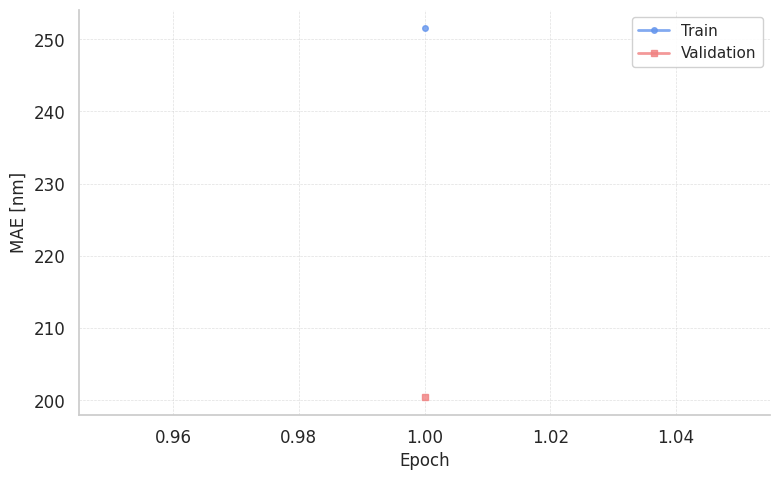

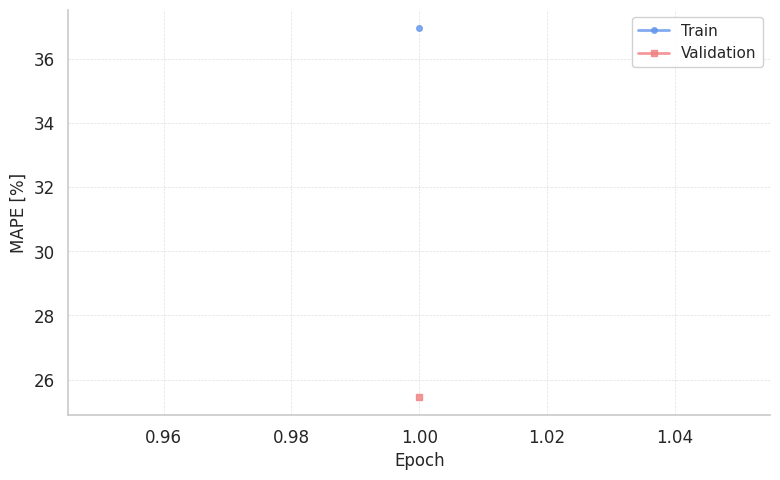

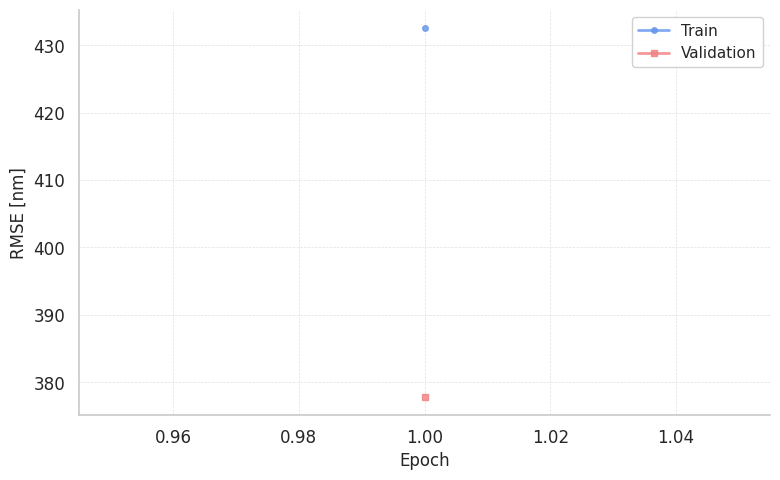

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

def do_graphics(model_trained, title: str, ylabel: tuple, folder_path: str, metric: str = 'metric_accuracy'):
    '''
    Description:
        This function generates the graphics of accuracy and loss over the epochs.

    Args:
        model_trained (keras.models.Model): Refers to the output of the model_training function
        title (str): Title of the accuracy graphic
        ylabel (tuple): Title of the y-axis of the loss and accuracy graphics.
        folder_path (str): Folder path to saved the images
        metric (str): Metric used to evaluated the model, by default is metric_accuracy
    '''

    # Set seaborn style
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)

    # Loss Graphic
    plt.figure(figsize=(8, 5))

    # Create epochs array for x-axis
    epochs = range(1, len(model_trained.history['loss']) + 1)

    # Plot loss with enhanced styling
    plt.plot(epochs, model_trained.history['loss'],
             color='cornflowerblue', linewidth=2, marker='o', markersize=4,
             alpha=0.8, label='Train')
    plt.plot(epochs, model_trained.history['val_loss'],
             color='lightcoral', linewidth=2, marker='s', markersize=4,
             alpha=0.8, label='Validation')

    # Enhanced grid
    plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)

    # Labels and title
    #plt.title('UN', fontsize=14, pad=20)
    plt.ylabel('MAE [nm]', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(framealpha=0.9, fontsize=11)

    # Remove spines for cleaner look
    sns.despine()

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'mae.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Accuracy plot
    plt.figure(figsize=(8, 5))

    # Plot accuracy with enhanced styling
    plt.plot(epochs, model_trained.history[metric],
             color='cornflowerblue', linewidth=2, marker='o', markersize=4,
             alpha=0.8, label='Train')
    plt.plot(epochs, model_trained.history['val_'+metric],
             color='lightcoral', linewidth=2, marker='s', markersize=4,
             alpha=0.8, label='Validation')

    # Enhanced grid
    plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)

    # Labels and title
    #plt.title(title, fontsize=14, pad=20)
    plt.ylabel('MAPE [%]', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(framealpha=0.9, fontsize=11)

    # Remove spines for cleaner look
    sns.despine()

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'mape.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

    # Accuracy plot
    plt.figure(figsize=(8, 5))

    # Plot accuracy with enhanced styling
    plt.plot(epochs, model_trained.history['root_mean_squared_error'],
             color='cornflowerblue', linewidth=2, marker='o', markersize=4,
             alpha=0.8, label='Train')
    plt.plot(epochs, model_trained.history['val_root_mean_squared_error'],
             color='lightcoral', linewidth=2, marker='s', markersize=4,
             alpha=0.8, label='Validation')

    # Enhanced grid
    plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.5)

    # Labels and title
    #plt.title(title, fontsize=14, pad=20)
    plt.ylabel('RMSE [nm]', fontsize=12)
    plt.xlabel('Epoch', fontsize=12)
    plt.legend(framealpha=0.9, fontsize=11)

    # Remove spines for cleaner look
    sns.despine()

    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, 'rmse.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


do_graphics(model_trained,
            'UNET-1.2M',
            ('MAE', 'MAPE'),
            final_path,
            metric='mape'
            )

## Evaluate

In [34]:
score = modelo_UNET.evaluate(x = x_test, y = y_test)
score

3750/3750 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step - loss: 199.2129 - mape: 25.3212 - root_mean_squared_error: 376.1632


[199.21292114257812, 25.3211669921875, 376.1631774902344]